In [27]:
import os
import getdist
from getdist import MCSamples, plots
import numpy as np
import matplotlib.pyplot as plt

# Definimos las rutas de las cadenas ya hechas:

ruta_planck      = r"C:\Users\hijos\Investigacion 1\Planck\base\plikHM_TTTEEE_lowl_lowE_lensing\base_plikHM_TTTEEE_lowl_lowE_lensing"
archivo_pantheon = r"C:\Users\hijos\Investigacion 1\multimeter\chains\Pantheon+SH0ES_FlatLambdaCDM.txt"

# Nota: Estás usando 'dovekie_cmbactspt...', si quieres que incluya BAO como dice tu leyenda, 
# asegúrate de cambiar la ruta a 'dovekie_bao_cmbactspt_lcdm_nautilus.txt' si lo tienes.
archivo_des_dovekie  = r"C:\Users\hijos\Investigacion 1\multimeter\chains\dovekie_bao_lcdm_nautilus.txt"  
archivo_des_5NYR     = r"C:\Users\hijos\Investigacion 1\multimeter\chains\bao_lcdm_nautilus.txt"   

# ==========================================
# 1. PLANCK
# ==========================================
chain_planck = getdist.mcsamples.loadMCSamples(ruta_planck, settings={'ignore_rows': 0.3})
chain_planck.updateSettings({'smooth_scale_2D': 0.5})
print("Columnas en Planck:", chain_planck.getParamNames().list())

# ==========================================
# 2. PANTHEON+ (PPS)
# ==========================================
datos_pps = np.loadtxt(archivo_pantheon, comments='#')
factor_pps = 100 if np.mean(datos_pps[:,1]) < 2 else 1  
muestras_pps = np.column_stack((datos_pps[:, 1] * factor_pps, datos_pps[:, 0])) 
chain_pantheon = MCSamples(samples=muestras_pps, names=['H0', 'omegam'], labels=['H_0', r'\Omega_m'])
chain_pantheon.updateSettings({'smooth_scale_2D': 0.5}) 
print("Columnas en Pantheon+:", chain_pantheon.getParamNames().list())

# ==========================================
# 3. DES-Dovekie (¡FIXED!)
# ==========================================
datos_des_dovekie = np.loadtxt(archivo_des_dovekie, comments='#')
factor_des = 100 if np.mean(datos_des_dovekie[:,1]) < 2 else 1

h0_raw = datos_des_dovekie[:, 1] * factor_des
om_raw = datos_des_dovekie[:, 0]

# 1. Extraer y normalizar pesos
log_w = datos_des_dovekie[:, 3] 
w = np.exp(log_w - np.max(log_w)) # Evita desbordamiento numérico
w_norm = w / np.sum(w)

# 2. EL TRUCO MÁGICO: Resampling
# Creamos una nueva cadena donde los puntos con más peso se repiten
# Esto convierte "Nested Sampling" en algo que parece "MCMC"
indices = np.random.choice(len(h0_raw), size=50000, p=w_norm, replace=True)

h0_clean = h0_raw[indices]
om_clean = om_raw[indices]

# 3. Crear la muestra para GetDist SIN la columna de pesos
# (Ya que el peso está implícito en la repetición de los puntos)
chain_des_dovekie = MCSamples(
    samples=np.column_stack((h0_clean, om_clean)), 
    names=['H0', 'omegam'], 
    labels=['H_0', r'\Omega_m']
)

# 4. Ajuste de suavizado (Crucial para que se vea como una elipse)
chain_des_dovekie.updateSettings({
    'smooth_scale_2D': 0.6, # Prueba entre 0.4 y 0.8 si queda muy "gorda"
    'smooth_scale_1D': 0.6
})
# ==========================================
# 4. DES-SN5YR (BAO solo) - ¡CON PESOS DE NAUTILUS!
# ==========================================
datos_des_5NYR = np.loadtxt(archivo_des_5NYR, comments='#')
factor_des5 = 100 if np.mean(datos_des_5NYR[:,1]) < 2 else 1

h0_5nyr = datos_des_5NYR[:, 1] * factor_des5
omegam_5nyr = datos_des_5NYR[:, 0]
# En este archivo (n_varied=3), el log_weight está en la columna 3
log_weight_5nyr = datos_des_5NYR[:, 3] 
pesos_5nyr = np.exp(log_weight_5nyr - np.max(log_weight_5nyr)) # Magia aplicada

muestras_des_5NYR = np.column_stack((h0_5nyr, omegam_5nyr))
chain_des_5NYR = MCSamples(
    samples=muestras_des_5NYR, 
    weights=pesos_5nyr,  # <--- Agregamos los pesos aquí
    names=['H0', 'omegam'], 
    labels=['H_0', r'\Omega_m']
)
chain_des_5NYR.updateSettings({'smooth_scale_2D': 0.5})
print("Columnas en DES_SN5YR:", chain_des_5NYR.getParamNames().list())

Columnas en Planck: ['omegabh2', 'omegach2', 'theta', 'tau', 'logA', 'ns', 'calPlanck', 'acib217', 'xi', 'asz143', 'aps100', 'aps143', 'aps143217', 'aps217', 'aksz', 'kgal100', 'kgal143', 'kgal143217', 'kgal217', 'galfTE100', 'galfTE100143', 'galfTE100217', 'galfTE143', 'galfTE143217', 'galfTE217', 'cal0', 'cal2', 'H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'sigma8', 'S8', 's8omegamp5', 's8omegamp25', 's8h5', 'rdragh', 'rmsdeflect', 'zrei', 'A', 'clamp', 'DL40', 'DL220', 'DL810', 'DL1420', 'DL2000', 'ns02', 'yheused', 'YpBBN', 'DHBBN', 'age', 'zstar', 'rstar', 'thetastar', 'DAstar', 'zdrag', 'rdrag', 'kd', 'thetad', 'zeq', 'keq', 'thetaeq', 'thetarseq', 'Hubble015', 'DM015', 'Hubble038', 'DM038', 'Hubble051', 'DM051', 'Hubble061', 'DM061', 'Hubble233', 'DM233', 'fsigma8z015', 'sigma8z015', 'fsigma8z038', 'sigma8z038', 'fsigma8z051', 'sigma8z051', 'fsigma8z061', 'sigma8z061', 'fsigma8z233', 'sigma8z233', 'f2000_143', 'f2000_x', 'f2000_217', 'chi2_lensing', 'chi2_simall', 'chi2_low

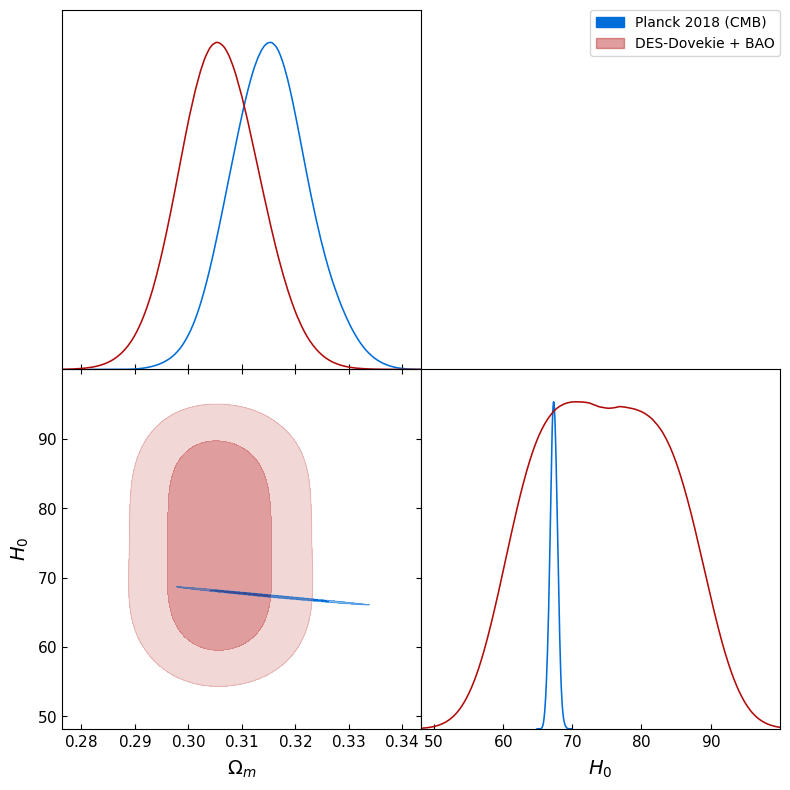

In [28]:
import matplotlib.pyplot as plt

# Queremos comparar H0 y omegam
parametros_a_graficar = ['omegam', 'H0']

# Figura
g = plots.get_subplot_plotter(width_inch=8)

g.settings.alpha_filled_add = 0.4
g.settings.legend_fontsize = 10 

# Creamos el gráfico ocupando las cuatro cadenas
g.triangle_plot([chain_planck, chain_des_dovekie, ],
                parametros_a_graficar,
                filled=True,
                legend_labels=['Planck 2018 (CMB)',  'DES-Dovekie + BAO'],
                contour_colors=["#006DD9",  "#B10A0A"]) 

# plt.show() no siempre es necesario en Jupyter, pero es buena práctica si corres como script
plt.show()

In [29]:
import pandas as pd
import numpy as np
#import healpy as hp
import matplotlib.pyplot as plt

# 1. Tu ruta local (Fíjate en la 'r' minúscula al principio)
ruta_local = r"C:\Users\hijos\Investigacion 1\Supernovas\DES-Dovekie_Metadata.csv"

# 2. Nombres de las columnas exactas del archivo
columnas = "PREFIX CID CIDint IDSURVEY TYPE FIELD CUTFLAG_SNANA ERRFLAG_FIT zHEL zHELERR zCMB zCMBERR zHD zHDERR VPEC VPECERR LENSDMU LENSDMUERR MWEBV HOST_NMATCH HOST_NMATCH2 HOST_OBJID HOST_ZPHOT HOST_ZPHOTERR HOST_ZSPEC HOST_ZSPECERR HOST_RA HOST_DEC HOST_ANGSEP HOST_DDLR HOST_CONFUSION HOST_LOGMASS HOST_LOGMASS_ERR HOST_LOGSFR HOST_LOGSFR_ERR HOST_LOGsSFR HOST_LOGsSFR_ERR HOST_COLOR HOST_COLOR_ERR HOST_MAG_g HOST_MAG_i HOST_SBFLUXCAL_g HOST_SBFLUXCAL_i HOST_SBMAG_g HOST_SBMAG_i PKMJDINI SNRMAX1 SNRMAX2 SNRMAX3 SNRSUM BANDLIST PKMJD PKMJDERR x1 x1ERR c cERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 NDOF FITCHI2 FITPROB RADIUS_POP PROB_SCONE PROB_SNIRFV19 PROB_SNNDESCC PROB_SNNJ17 PROB_SNNV19 CUTMASK MU MUMODEL MUERR MUERR_RENORM MUERR_RAW MUERR_VPEC MURES MUPULL M0DIF M0DIFERR CHI2_BEAMS PROBCC_BEAMS biasCor_nevt biasCor_mu biasCorErr_mu biasCor_muCOVSCALE biasCor_muCOVADD IDSAMPLE IZBIN".split()

# 3. Leer el archivo local
df = pd.read_csv(ruta_local, 
                 sep='\s+',           # Separado por espacios
                 comment='#',         # Ignora comentarios iniciales
                 names=columnas,      # Aplica nuestros nombres de columnas
                 low_memory=False)    # Evita warnings de tipos de datos

# 4. LIMPIEZA: Filtramos las supernovas que no tienen coordenadas válidas (-999)
df_limpio = df[(df['HOST_RA'] != -999) & (df['HOST_DEC'] != -999)]

# Extraemos las variables que nos importan
ra = df_limpio['HOST_RA'].astype(float).values
dec = df_limpio['HOST_DEC'].astype(float).values
redshifts = df_limpio['zHD'].astype(float).values

print(f"Total de supernovas leídas y listas para graficar: {len(ra)}")

# 5. CONVERSIÓN A HEALPY (De grados a Radianes esféricos)
phi = np.radians(ra)
theta = np.radians(90.0 - dec)

# 6. GRAFICAR EL CIELO
fig = plt.figure(figsize=(12, 8))

# Generar el fondo del mapa (Mollweide projection)
#hp.mollview(title="Huella Observacional de Supernovas (DES-Dovekie)", 
 #           cbar=False, 
  #          coord=['C'],     # Sistema Ecuatorial
   #         bgcolor='white', # Fondo blanco para documentos/papers
    #        xsize=2000,      # Alta resolución
     #       fig=fig.number)

# Proyectar los puntos de las supernovas
#hp.projscatter(theta, phi, 
 #              c=redshifts,     # El color indica el redshift
  #             cmap='magma',    # Paleta de colores atractiva
   #            s=10,            # Tamaño del punto
    #           alpha=0.6)       # Transparencia para ver densidad

# Barra de color
#plt.colorbar(label='Redshift ($z_{HD}$)', orientation='horizontal', shrink=0.6, pad=0.05)

#plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hijos\AppData\Local\Temp\ipykernel_23112\2412251835.py:14: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',           # Separado por espacios


AttributeError: module 'pandas' has no attribute 'read_csv'

Ahora vamos a calcular $Q_{DM}$ ocupando tensiometer, álgebra "a mano" y multimeter

In [ ]:
# Q_DM_tensiometer

from tensiometer import gaussian_tension
import scipy.stats as stats

parametros_comunes = ['H0', 'omegam']

# Tensiometer exige por defecto que los límites de las cadenas coincidan.
# Si ya tienes esto en tu código, no necesitas repetirlo.
for param in parametros_comunes:
    limite = chain_planck.ranges.upper.get(param)
    chain_pantheon.ranges.setRange(param, [chain_planck.ranges.lower.get(param), limite])

q_dm_tens_1, dof_tens_1 = gaussian_tension.Q_DM(chain_planck, chain_pantheon, param_names=parametros_comunes)

#Conversión a sigmas
tension_tens_1 = stats.norm.isf(stats.chi2.sf(q_dm_tens_1, dof_tens_1) / 2)

print(f"Q_DM_tensiometer: {q_dm_tens_1:.3f}")
print(f"Tensión Tensiometer: {tension_tens_1:.3f} sigmas")



In [ ]:
# Q_DM utilizando Multimeter
from scipy.linalg import sqrtm, inv
from scipy.stats import chi2
# Importamos utils que está en multimeter.utils.utils
from multimeter.utils import utils

parametros_comunes = ['H0', 'omegam']

#Extraemos medias y covarianzas
theta_A = chain_planck.getMeans([chain_planck.index[p] for p in parametros_comunes])
theta_B = chain_pantheon.getMeans([chain_pantheon.index[p] for p in parametros_comunes])

cov_A = chain_planck.cov(parametros_comunes)
cov_B = chain_pantheon.cov(parametros_comunes)

#Aplicamos la ecuacio´n exacta que aparece en el repositorio:
# r_1 = sqrtm(inv(cov_A + cov_B)) * (mean_A - mean_B)
inversa_suma_cov = inv(cov_A + cov_B)
raiz_matriz = sqrtm(inversa_suma_cov)
r_1 = np.dot(raiz_matriz, (theta_A - theta_B))

# Q_DM es la norma al cuadrado de este vector
q_dm_multi = np.linalg.norm(r_1)**2

#convertir a sigmas
dof = len(parametros_comunes)
pte = chi2(dof).sf(q_dm_multi)
tension_sigmas = utils.PTE_to_n_sigma(pte)

print(f"Q_DM (Multimeter): {q_dm_multi:.3f}")
print(f"Tensión (Multimeter): {tension_sigmas:.3f} sigmas")

In [ ]:
import numpy as np
from scipy.linalg import sqrtm, inv
from scipy.stats import chi2
from multimeter.utils import utils

# Definimos los parámetros que vamos a comparar en 2D
parametros_comunes = ['H0', 'omegam']

def calcular_tension_qdm(chain_base, chain_test, nombre_test):
    """
    Calcula la tensión Q_DM y en sigmas entre dos cadenas MCMC
    utilizando la formulación matricial exacta (estilo Multimeter).
    """
    # Extraemos medias
    theta_A = chain_base.getMeans([chain_base.index[p] for p in parametros_comunes])
    theta_B = chain_test.getMeans([chain_test.index[p] for p in parametros_comunes])

    # Extraemos matrices de covarianza
    cov_A = chain_base.cov(parametros_comunes)
    cov_B = chain_test.cov(parametros_comunes)

    # Matemática de Q_DM (Multimeter)
    inversa_suma_cov = inv(cov_A + cov_B)
    
    # sqrtm a veces deja residuos imaginarios minúsculos por precisión computacional,
    # usamos np.real() para quedarnos solo con la parte real.
    raiz_matriz = np.real(sqrtm(inversa_suma_cov)) 
    r_1 = np.dot(raiz_matriz, (theta_A - theta_B))

    # Q_DM es la norma al cuadrado del vector r_1
    q_dm = np.linalg.norm(r_1)**2

    # Convertir a sigmas
    dof = len(parametros_comunes)
    pte = chi2(dof).sf(q_dm)
    tension_sigmas = utils.PTE_to_n_sigma(pte)
    
    # Imprimir resultados
    print(f"--- Planck vs {nombre_test} ---")
    print(f"Q_DM: {q_dm:.3f}")
    print(f"Tensión: {tension_sigmas:.3f} sigmas\n")
    
    return q_dm, tension_sigmas

# ==============================================================================
# EJECUTAR LOS CÁLCULOS
# ==============================================================================
print("RESULTADOS DE LA TENSIÓN (Métrica Q_DM en 2D: H0 y Omega_m)\n")

# 1. Planck vs Pantheon+
calcular_tension_qdm(chain_planck, chain_pantheon, "Pantheon+SH0ES")

# 2. Planck vs DES Dovekie
calcular_tension_qdm(chain_planck, chain_des_dovekie, "DES Dovekie (BAO)")

# 3. Planck vs DES SN 5YR
# (Asumiendo que cargaste esta cadena bajo el nombre chain_des_5NYR)
calcular_tension_qdm(chain_planck, chain_des_5NYR, "DES SN 5YR")